In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

In [34]:
df = pd.read_csv("/content/Weather Data.csv.xls")

print(df.head())
print(df.info())

       Date/Time  Temp_C  Dew Point Temp_C  Rel Hum_%  Wind Speed_km/h  \
0  1/1/2012 0:00    -1.8              -3.9         86                4   
1  1/1/2012 1:00    -1.8              -3.7         87                4   
2  1/1/2012 2:00    -1.8              -3.4         89                7   
3  1/1/2012 3:00    -1.5              -3.2         88                6   
4  1/1/2012 4:00    -1.5              -3.3         88                7   

   Visibility_km  Press_kPa               Weather  
0            8.0     101.24                   Fog  
1            8.0     101.24                   Fog  
2            4.0     101.26  Freezing Drizzle,Fog  
3            4.0     101.27  Freezing Drizzle,Fog  
4            4.8     101.23                   Fog  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   obje

In [35]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

df['year'] = df['Date/Time'].dt.year
df['month'] = df['Date/Time'].dt.month
df['day'] = df['Date/Time'].dt.day
df['hour'] = df['Date/Time'].dt.hour

df.drop('Date/Time', axis=1, inplace=True)

In [36]:
def simplify_weather(x):
    if "Rain" in x:
        return "Rain"
    elif "Snow" in x:
        return "Snow"
    elif "Fog" in x:
        return "Fog"
    elif "Cloud" in x:
        return "Cloudy"
    else:
        return "Clear"

df['Weather'] = df['Weather'].apply(simplify_weather)

print(df['Weather'].value_counts())

Weather
Cloudy    3797
Clear     3501
Rain       689
Snow       556
Fog        241
Name: count, dtype: int64


In [37]:
le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])

In [38]:
X = df.drop('Weather', axis=1)
y = df['Weather']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [39]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [41]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [42]:
svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

In [43]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [44]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

In [45]:
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

print("\nLogistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

print("\nSVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

print("\nDecision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

print("\nKNN Accuracy:", accuracy_score(y_test, knn_pred))
print(classification_report(y_test, knn_pred))

Random Forest Accuracy: 0.7877063175867957
              precision    recall  f1-score   support

           0       0.78      0.86      0.82       675
           1       0.78      0.78      0.78       772
           2       0.85      0.81      0.83        54
           3       0.71      0.48      0.57       133
           4       0.88      0.74      0.81       123

    accuracy                           0.79      1757
   macro avg       0.80      0.74      0.76      1757
weighted avg       0.79      0.79      0.78      1757


Logistic Regression Accuracy: 0.601593625498008
              precision    recall  f1-score   support

           0       0.60      0.63      0.62       675
           1       0.59      0.62      0.60       772
           2       0.69      0.54      0.60        54
           3       0.53      0.35      0.43       133
           4       0.72      0.64      0.68       123

    accuracy                           0.60      1757
   macro avg       0.63      0.56      

In [46]:
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

In [47]:
def plot_roc(model, X_test, title):
    y_prob = model.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test_bin[:, 0], y_prob[:, 0])
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)

    plt.legend()
    plt.show()

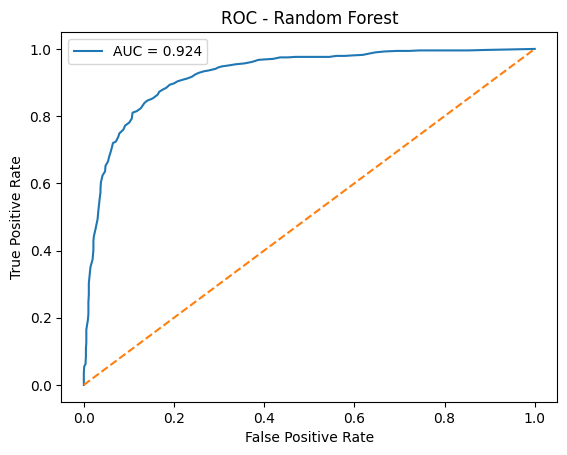

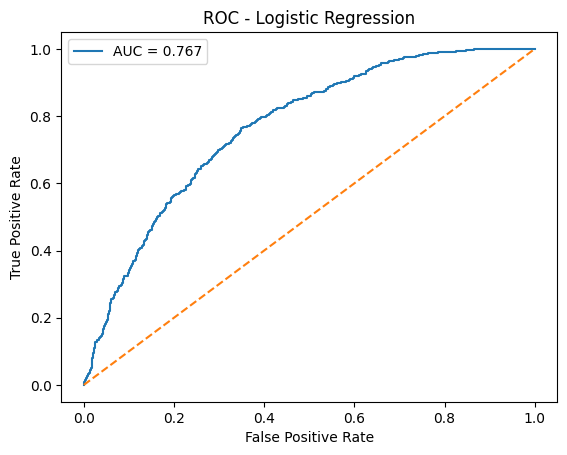

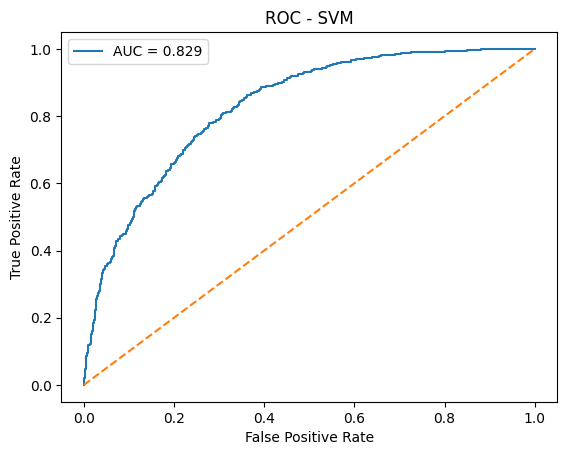

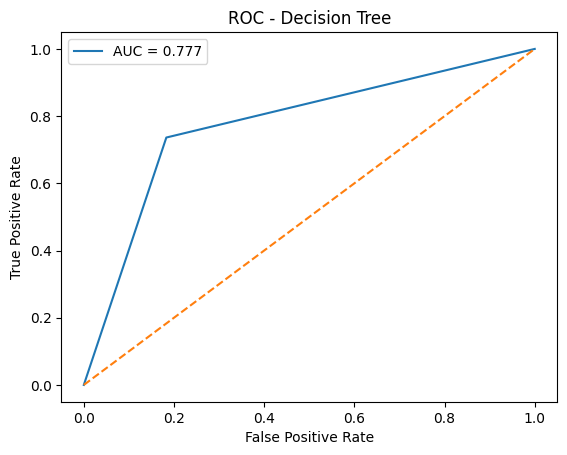

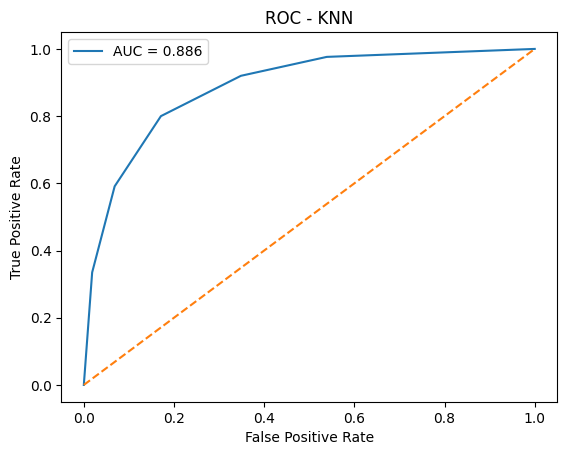

In [48]:
plot_roc(rf, X_test, "ROC - Random Forest")
plot_roc(lr, X_test_scaled, "ROC - Logistic Regression")
plot_roc(svm, X_test_scaled, "ROC - SVM")
plot_roc(dt, X_test, "ROC - Decision Tree")
plot_roc(knn, X_test_scaled, "ROC - KNN")

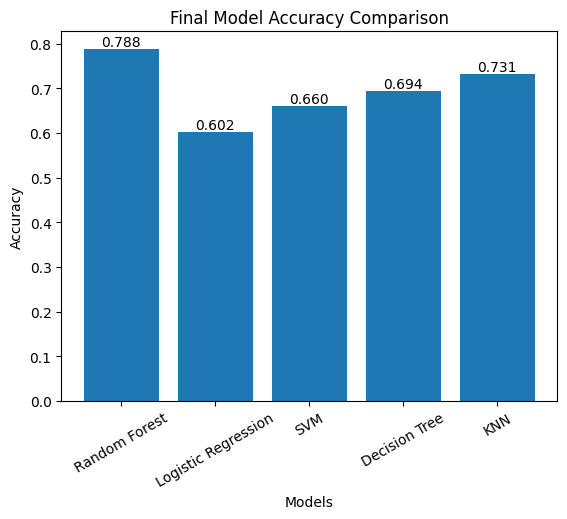

In [49]:
rf_acc = accuracy_score(y_test, rf_pred)
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)
dt_acc = accuracy_score(y_test, dt_pred)
knn_acc = accuracy_score(y_test, knn_pred)

models = ["Random Forest", "Logistic Regression", "SVM", "Decision Tree", "KNN"]
accuracies = [rf_acc, lr_acc, svm_acc, dt_acc, knn_acc]

plt.figure()
plt.bar(models, accuracies)

for i, v in enumerate(accuracies):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Final Model Accuracy Comparison")

plt.xticks(rotation=30)
plt.show()